In [1]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from LAMP import Experiment

ROOT_FOLDER = str(Path.cwd().parent.parent)
sys.path.append(ROOT_FOLDER)
ex = Experiment(ROOT_FOLDER)

Initializing LAMP, version 0.1.0
Using DAQ: FireballIII
Adding (User) Diagnostic: HRM5 [ESpec_]
Adding (User) Diagnostic: HRM6 [ESpec_]
Adding (User) Diagnostic: HRM3 [ProfileCam_]
Adding (User) Diagnostic: HRM4 [ProfileCam_]


In [15]:
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# typing imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from numpy.typing import NDArray
from typing import Dict, List
from LAMP.diagnostic import Diagnostic
from enum import Enum

class ROI(ABC):
    @abstractmethod
    def apply(self, img: NDArray[float]) -> NDArray[float]:
        """return img cropped around ROI"""
        pass

    @abstractmethod
    def lineout(self, img: NDArray[float]) -> NDArray[float]:
        """return lineout inside ROI"""
        pass

    @abstractmethod
    def add_to_axis(self, ax):
        """draws ROI as an overlay on a matplotlib axis"""
        pass

class RectangleROI(ROI):
    def __init__(self, x0: int, x1: int, y0: int, y1: int):
        self.x0 = x0
        self.x1 = x1
        self.y0 = y0
        self.y1 = y1

    def apply(self, img: NDArray[float]):
        return img[self.y0:self.y1, self.x0:self.x1]

    def lineout(self, img: NDArray[float], axis: int = 1) -> NDArray[float]:
        """TODO: axis to be an input?"""
        roi_img = self.apply(img)
        return np.mean(roi_img, axis=axis)

    def add_to_axis(self, ax):
        rect = Rectangle(
            (self.x0, self.y0),
            self.x1 - self.x0,
            self.y1 - self.y0,
            edgecolor="red",
            facecolor="none",
            linewidth=2,
        )
        ax.add_patch(rect)
    

@dataclass
class ProfileCamGroup:
    shot_numbers: List[int]
    processed_images: List[NDArray[float]]
    lineouts: NDArray[float]
    lineout_mean: NDArray[float]
    lineout_stderr: NDArray[float]
    

class Normalisation(Enum):
    NONE = "none"
    AREA = "area"
    MAX = "max"


class ProfileCamAnalysis:
    """
    will allow you to load multiple images, grouping them by shot type (eg "gas" "plasma")
    can take lineouts in a region of interest
    then average over shots of a given type
    and plot a comparison between these types
    """

    def __init__(self, diagnostic: Diagnostic, calib_id: str):
        self.diagnostic = diagnostic
        self.calib_id = calib_id

    def _normalise(self, lineout: NDArray[float], mode: Normalisation) -> NDArray[float]:
        match mode:
            case Normalisation.NONE:
                return lineout
                
            case Normalisation.AREA:
                area = np.trapezoid(lineout)
                return lineout / area if area != 0 else lineout

            case Normalisation.MAX:
                m = np.max(lineout)
                return lineout / m if m != 0 else lineout

            
    def compare_groups(self,
                       shot_groups: Dict[str, List[int]],
                       roi: ROI,
                       normalisation: Normalisation = Normalisation.NONE
                      ) -> Dict[str, ProfileCamGroup]:
        results = {}
        
        for shot_type, shots_list in shot_groups.items():
            all_lineouts = []
            all_images = []

            for shot in shots_list:

                shot_dict = {"shot" : [shot]}
                img, x,y = self.diagnostic.get_proc_shot(shot_dict, self.calib_id)
                all_images.append(img)

                lineout = roi.lineout(img)
                lineout = self._normalise(lineout, normalisation)
                all_lineouts.append(lineout)

            all_lineouts = np.asarray(all_lineouts)

            results[shot_type] = ProfileCamGroup(
                shot_numbers = shots_list,
                processed_images = all_images,
                lineouts = all_lineouts,
                lineout_mean = np.mean(all_lineouts, axis=0),
                lineout_stderr = np.std(all_lineouts, axis=0, ddof=1) / np.sqrt(len(all_lineouts))
            )

        return results


def plot_group_overview(group: ProfileCamGroup, roi: ROI):
    images = group.processed_images
    lineouts = group.lineouts

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, len(images), height_ratios=[1, 5], figure=fig)

    for i, img in enumerate(images):
        ax = fig.add_subplot(gs[0, i])

        ax.imshow(img, cmap="jet", vmax=1200)
        ax.set_xticks([])
        ax.set_yticks([])

        roi.add_to_axis(ax)

        ax.set_title(group.shot_numbers[i])

    ax_lineouts = fig.add_subplot(gs[1, :])
    xs = np.arange(lineouts.shape[1])

    for lineout in lineouts:
        ax_lineouts.plot(xs, lineout)

    ax_lineouts.set_xlabel("pixel")
    ax_lineouts.set_ylabel("intensity")

    plt.show()


def plot_group_comparison(groups: Dict[str, ProfileCamGroup]):

    fig,ax = plt.subplots(figsize=(8,5))

    for name, group in groups.items():
        xs = np.arange(group.lineout_mean.size)
        mean = group.lineout_mean
        stderr = group.lineout_stderr

        ax.plot(xs, mean, label=name)
        ax.fill_between(xs, mean-stderr, mean+stderr, alpha=0.3)

    ax.set_xlabel("Pixel")
    ax.set_ylabel("Intensity")
    ax.legend()
    plt.show()

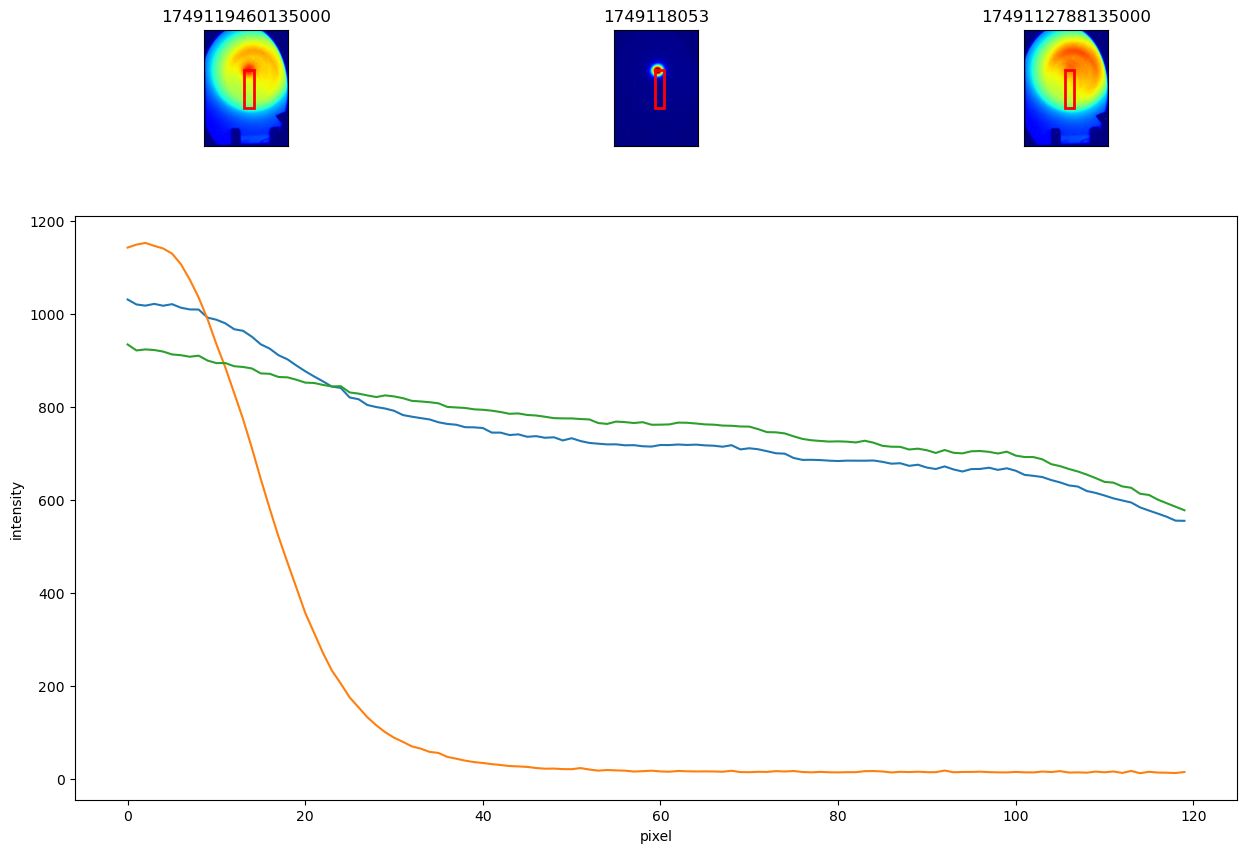

In [12]:
HRM4 = ex.get_diagnostic('HRM4')
analysis = ProfileCamAnalysis(HRM4, "HRM4_calib.toml")
roi = RectangleROI(130, 160, 130, 250)
shot_groups = {
    "test" : [1749119460135000, 1749118053, 1749112788135000]
}

results = analysis.compare_groups(
    shot_groups,
    roi,
    Normalisation.NONE
)

plot_group_overview(results["test"], roi)

In [51]:
shot_log.keys()

Index(['Shot number', 'Global UNIX Timestamp (UTC timezone) of HiRadMat cycle',
       'Acquisition UNIX Timestamp of HiRadMat cycle (UTC timezone)',
       'Exact Date/Time (local)', 'Shot purpose', 'Pre-shot comments',
       'Post-shot comments',
       'Requested (Pilot = 8e9, Nom = 1e11, Full = 5e11)', 'Actual',
       'sigma_x (mm)', 'Error sigma_x (mm)', 'sigma_y (mm)',
       'Error sigma_y (mm)', 'Bunch duration (4 sigma) (ns)',
       'Argon pressure (mbar, or Vac)', 'Plasma (Y/N)', 'Forward power (W)',
       'Reflected power (W)', 'RMS current (A)', 'HRM3 (Plasma cell upstream)',
       'HRM4 (Plasma cell downstream)', 'HRM4', 'HRM5 (Spectrometer 1)',
       'HRM3,4,5,6 (ms)'],
      dtype='object')

In [56]:
shot_groups

{'PPLW': [1749113394768131,
  1749113490768141,
  1749113586768162,
  1749113682768134,
  1749113778768117],
 'PGLW': [1749112098768122,
  1749110000000000,
  1749112266768116,
  1749112362768173,
  1749110000000000]}

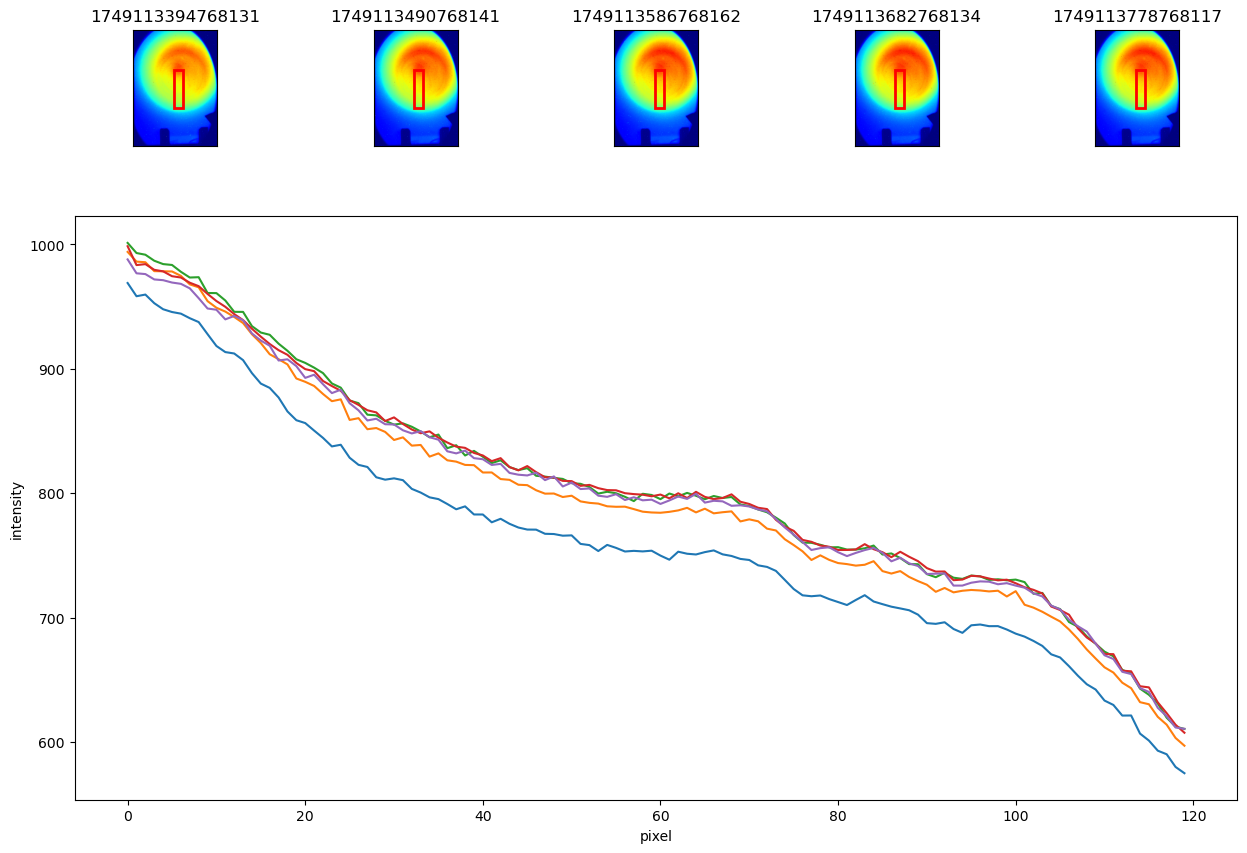

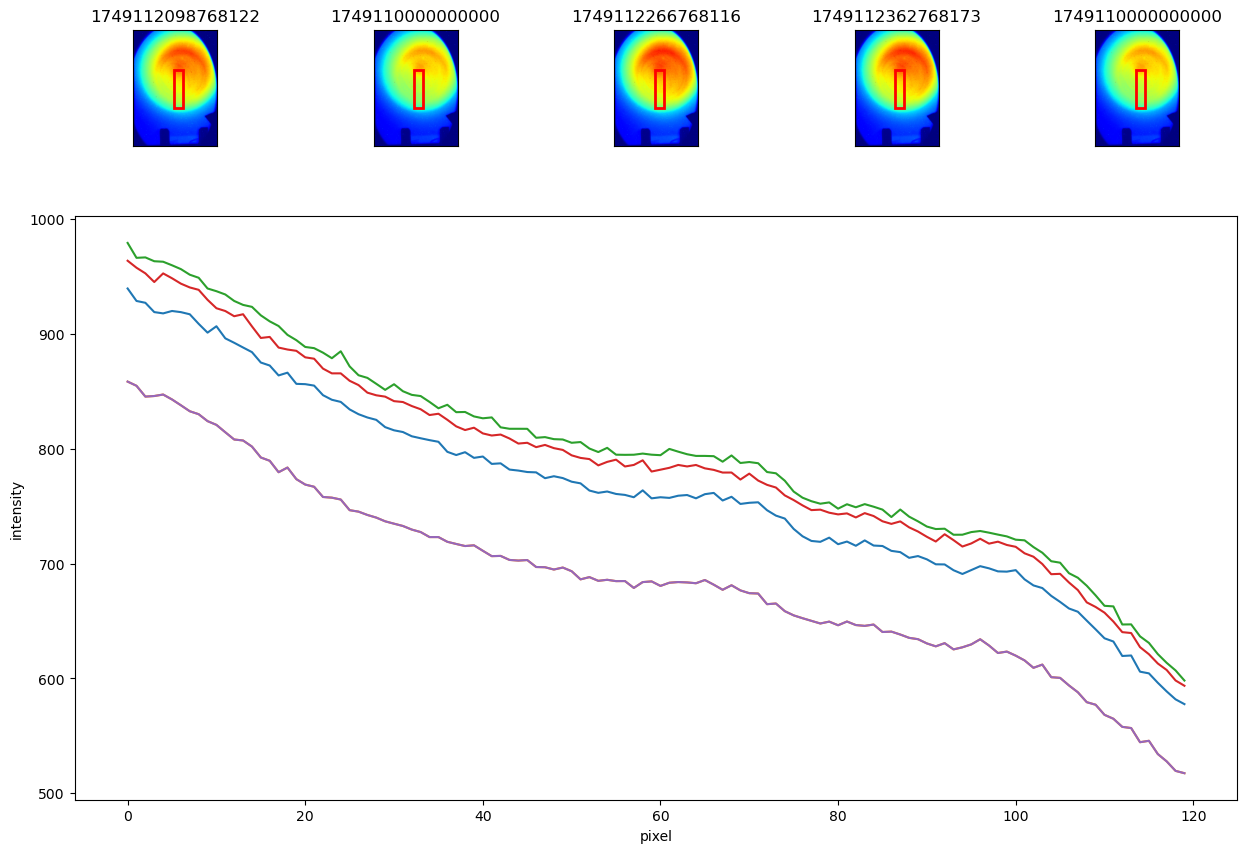

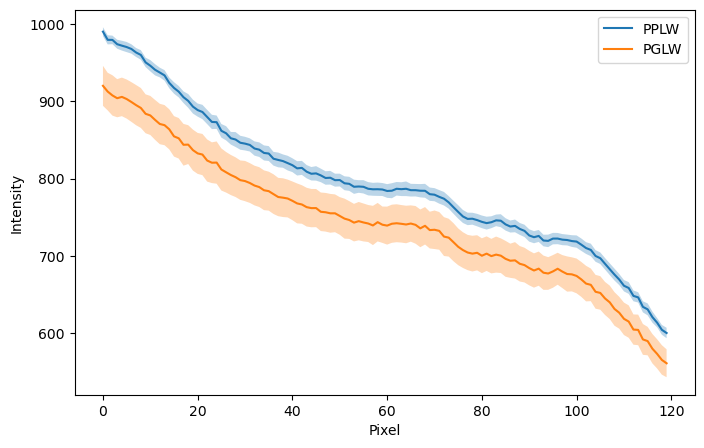

In [19]:
shot_log = pd.read_csv("~/Documents/FIREBALLIII_ANALYSIS/BrynShotLog.csv")
def shotno_to_timestamp(shotnos, df):
    mapped = df.loc[df['Shot number'].isin(shotnos), 'Acquisition UNIX Timestamp of HiRadMat cycle (UTC timezone)'].tolist()
    return [int(s) for s in mapped]

shot_groups = {
    "PPLW" : shotno_to_timestamp(list(range(169, 174)), shot_log),
    "PGLW" : shotno_to_timestamp(list(range(157, 162)), shot_log)
}

HRM4 = ex.get_diagnostic('HRM4')
analysis = ProfileCamAnalysis(HRM4, "HRM4_calib.toml")
roi = RectangleROI(130, 160, 130, 250)

results = analysis.compare_groups(
    shot_groups,
    roi,
    Normalisation.NONE
)

plot_group_overview(results["PPLW"], roi)
plot_group_overview(results["PGLW"], roi)
plot_group_comparison(results)

In [4]:
HRM3 = ex.get_diagnostic('HRM3')
HRM4 = ex.get_diagnostic('HRM4')
# device="HRM4"

shot_dict = {'shot': [1749119460135000]}

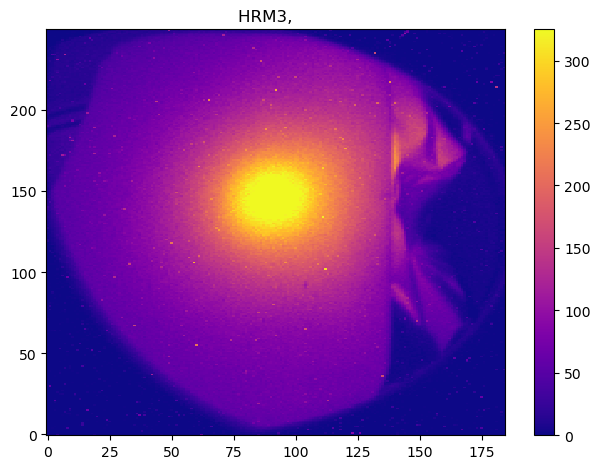

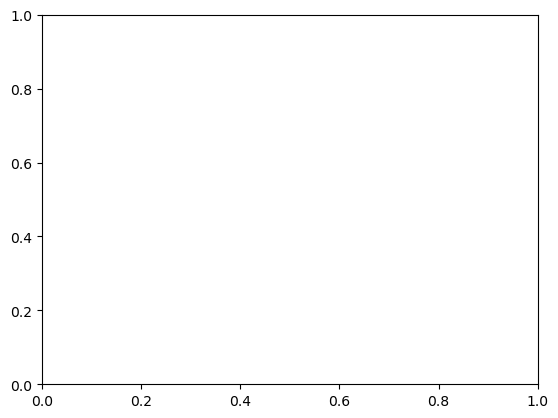

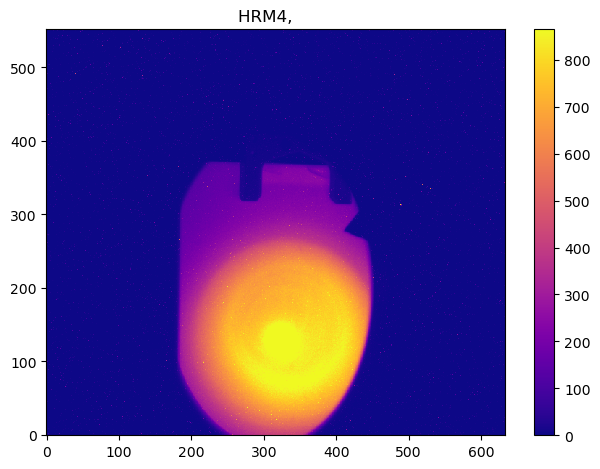

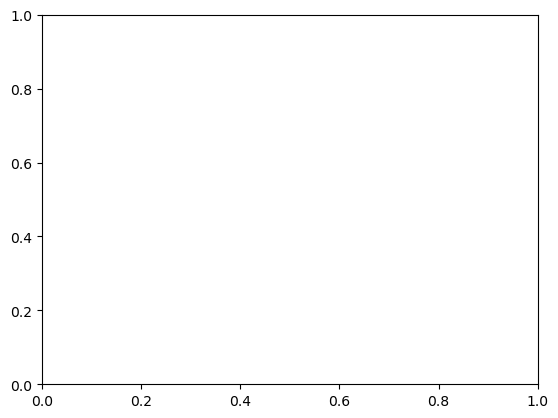

In [5]:
_ = HRM3.plot_proc_shot(shot_dict, calib_id="HRM3_calib.toml")
plt.show()
_ = HRM4.plot_proc_shot(shot_dict, calib_id="HRM4_calib.toml")
plt.show()

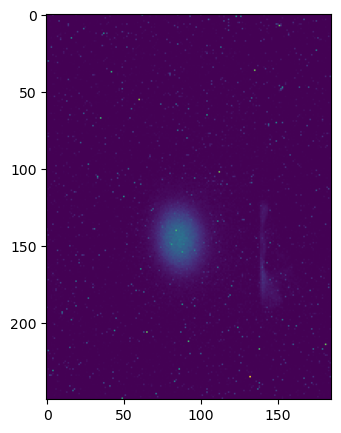

In [4]:
shot_dict = {'shot': [1749119196135000]}
# shot_dict = {'shot': [1749118053]}

# img, x, y = HRM3.get_proc_shot(shot_dict, calib_id = "HRM3_calib.toml")
img, x, y = HRM3.get_proc_shot(shot_dict, calib_id = "HRM3_calib.toml")

fig,ax = plt.subplots(figsize=(5,5))
ax.imshow(img)
plt.show()

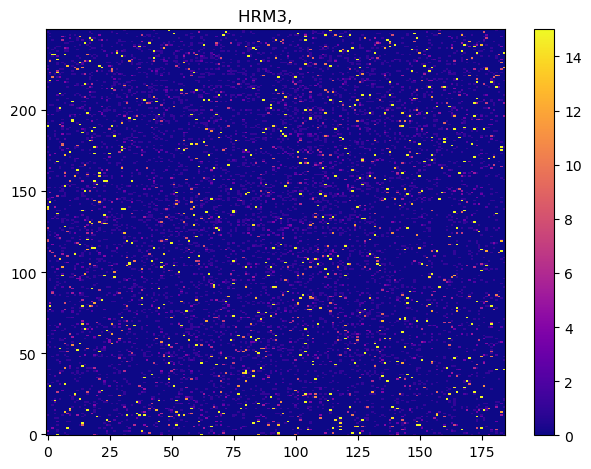

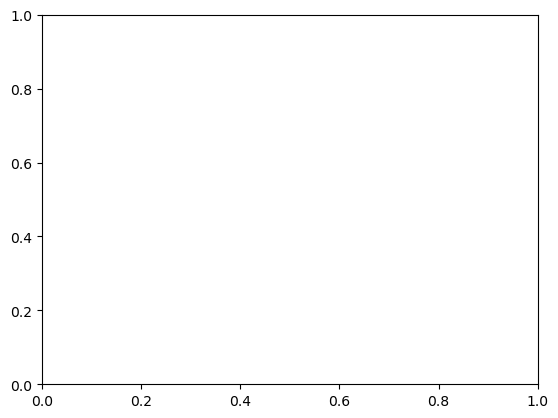

In [5]:
shot_dict = {'shot': [1749118053]}

fig, ax = HRM3.plot_proc_shot(shot_dict, calib_id="HRM4_calib.toml")

In [20]:
shot_dict = {'shot': [1749119460135000, 1749118053]}
result = HRM4.get_proc_shot(shot_dict, calib_id = "HRM4_calib.toml")


In [5]:
HRM4.__dict__

{'ex': <LAMP.experiment.Experiment at 0x7f8361d5fc80>,
 'DAQ': <LAMP.DAQs.FireballIII.FireballIII at 0x7f83639189b0>,
 'config': {'type': 'ProfileCam_',
  'data_folder': '/chromox_cameras/HRM4/',
  'data_stem': 'OD',
  'data_type': 'csv',
  'data_ext': '.csv',
  'calib_subfolder': './ProfileCam/',
  'calib_file': 'HRM4_calib.toml',
  'name': 'HRM4'},
 'calib_start': 1749112092,
 'calib_end': 1749153428,
 'calib_id': '1749112092135000',
 'calib_dict': None,
 'x': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93, 